# Paired microbe ↔ metabolite integration (Franzosa 2019 IBD)

Gut microbes produce and consume metabolites, so when a cohort is measured on both 16S (or shotgun metagenomics) and LC-MS metabolomics, the biologically interesting question becomes: *which microbe is associated with which metabolite?* Naive correlations on raw counts are misleading because the microbiome table is **compositional** — forced to sum to the sequencing depth — so spurious associations pop up whenever any single microbe moves.

This tutorial walks through three complementary approaches on the **real paired Franzosa *et al.* 2019 PRISM cohort** (220 stool samples from IBD patients + controls, shotgun-derived genera + LC-MS metabolomics). All three live under `ov.micro`:

| API | Method | Compositionally robust? | Needs torch? |
|---|---|---|---|
| `ov.micro.paired_spearman` | Spearman ρ on CLR-transformed microbes vs log1p metabolites | partial (CLR handles the microbe side) | no |
| `ov.micro.paired_cca` | sklearn Canonical Correlation Analysis | no (linear joint covariance) | no |
| `ov.micro.MMvec` | Morton *et al.* 2019 — learns log P(metabolite \| microbe) ∝ u · v + β | **yes** (conditional probabilities are scale-free) | yes |

Dataset provenance: curated TSVs by the Borenstein lab ([microbiome-metabolome-curated-data](https://github.com/borenstein-lab/microbiome-metabolome-curated-data)), derived from [Franzosa *et al.* 2019](https://www.nature.com/articles/s41564-018-0306-4). 88 Crohn's disease (CD), 76 ulcerative colitis (UC), 56 controls. The paper's headline biological finding — short-chain fatty acid depletion + bile acid dysbiosis in IBD gut — should re-emerge from every method below.

## 1. Setup + fetch the real paired dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import omicverse as ov

ov.plot_set()
print('omicverse:', ov.__version__)

/home/users/steorra/miniforge3/envs/omicverse/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)


🔬 Starting plot initialization...
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] NVIDIA H100 80GB HBM3
      Memory: 79.1 GB | Compute: 9.0

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 2.1.2rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

omicverse: 2.1.2rc1


In [2]:
adata_mb, adata_mt = ov.micro.fetch_franzosa_ibd_2019(
    data_dir='/scratch/users/steorra/analysis/omicverse_dev/cache/franzosa_2019',
)
print('microbes   :', adata_mb.shape)
print('metabolites:', adata_mt.shape)
adata_mb.obs['Study.Group'].value_counts()

microbes   : (220, 11720)
metabolites: (220, 8848)


Study.Group
CD         88
UC         76
Control    56
Name: count, dtype: int64

## 2. Filter to a tractable, well-characterised subset

The raw tables are huge (≈12k genera × 8.8k metabolites). For a
pedagogical analysis we trim both sides:

- **microbes**: keep only genera present at >10% prevalence (`ov.micro.filter_by_prevalence`)
- **metabolites**: keep only *annotated* clusters (HMDB names), since we want to talk about biology later

These filters are also what Franzosa *et al.* used in the headline
analyses of the 2019 paper.

In [3]:
# microbes: top 150 by total pseudo-count (MMvec scales as M × N × K).
ab_rank = np.argsort(-np.asarray(adata_mb.X).sum(axis=0))[:150]
adata_mb_f = adata_mb[:, ab_rank].copy()
# metabolites: keep annotated clusters, then top 200 by variance.
adata_mt_named = adata_mt[:, adata_mt.var['name'].notna()].copy()
var_rank = np.argsort(-np.asarray(adata_mt_named.X).var(axis=0))[:200]
adata_mt_f = adata_mt_named[:, var_rank].copy()
adata_mt_f.var_names = adata_mt_f.var['name'].astype(str).values
print('microbes after filter   :', adata_mb_f.shape)
print('metabolites after filter:', adata_mt_f.shape)

microbes after filter   : (220, 150)
metabolites after filter: (220, 200)


## 3. Exploratory data analysis — are IBD and Control separable?

Before asking which microbe goes with which metabolite, check that the
two tables actually carry a disease signal. Bray-Curtis PCoA on the
microbes and a simple PCA on log1p metabolites should both partition
CD / UC / Control — if they didn't, any cross-modality association
would be noise.

In [4]:
ov.micro.Beta(adata_mb_f).run(metric='braycurtis', rarefy=False)
coords = np.asarray(
    ov.micro.Ordinate(adata_mb_f, dist_key='braycurtis').pcoa(n=2)
)

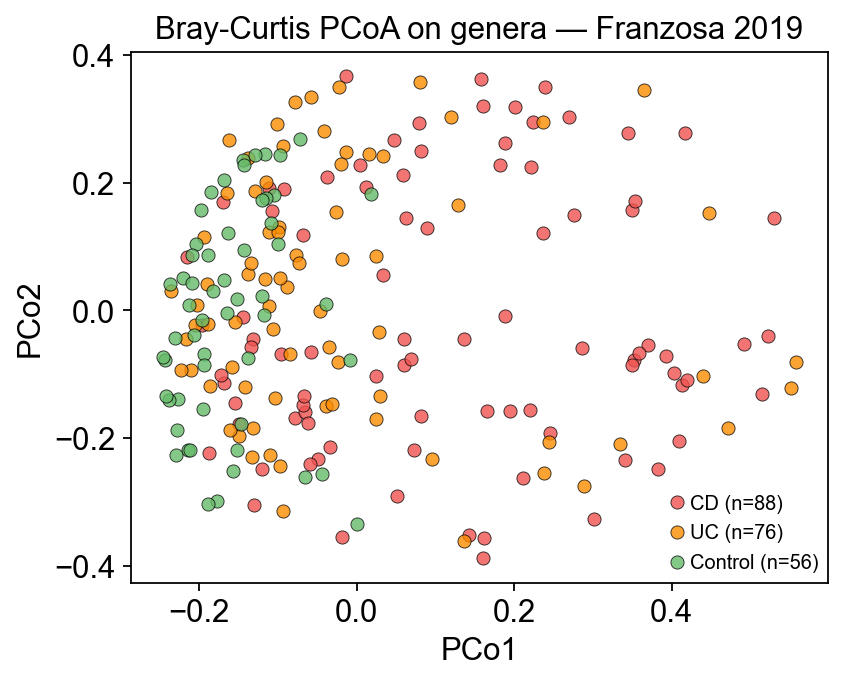

In [5]:
fig, ax = plt.subplots(figsize=(5.5, 4.5))
palette = {'CD': '#EF5350', 'UC': '#FB8C00', 'Control': '#66BB6A'}
for grp, color in palette.items():
    mask = (adata_mb_f.obs['Study.Group'].values == grp)
    ax.scatter(coords[mask, 0], coords[mask, 1],
               s=35, alpha=0.8, c=color, label=f'{grp} (n={mask.sum()})',
               edgecolors='k', linewidths=0.4)
ax.set_xlabel('PCo1'); ax.set_ylabel('PCo2')
ax.set_title('Bray-Curtis PCoA on genera — Franzosa 2019')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## 4. Spearman ρ on CLR(microbes) × log1p(metabolites)

`paired_spearman` CLR-transforms the microbes, log1p-transforms the
metabolites, then computes rank correlation for every microbe ×
metabolite pair with BH-FDR across all pairs.

In [6]:
spear = ov.micro.paired_spearman(adata_mb_f, adata_mt_f, min_prevalence=0.1)
sig = spear[spear['fdr_bh'] < 0.05]
print(f'{len(sig):,} pairs at FDR 0.05 out of {len(spear):,}')
spear.head(10)

11,214 pairs at FDR 0.05 out of 30,000


           microbe metabolite       rho       p_value        fdr_bh
0       Ventricola   urobilin  0.712073  2.474755e-35  7.424264e-31
1          CAG-170   urobilin  0.709289  5.937311e-35  8.905967e-31
2    Fusobacterium   urobilin -0.706496  1.414351e-34  1.414351e-30
3    Fusobacterium  urobilin* -0.704017  3.029556e-34  1.919234e-30
4  Fusobacterium_C  urobilin* -0.703839  3.198723e-34  1.919234e-30
5  Fusobacterium_C   urobilin -0.698382  1.662667e-33  8.313337e-30
6       Ventricola  urobilin*  0.696968  2.532582e-33  1.085392e-29
7     Faecalimonas   urobilin -0.691238  1.360889e-32  5.103334e-29
8     Faecalimonas  urobilin* -0.689978  1.959167e-32  6.530557e-29
9          CAG-170  urobilin*  0.688545  2.958520e-32  8.875559e-29

## 5. CCA — global joint covariance

In [7]:
cca = ov.micro.paired_cca(adata_mb_f, adata_mt_f, n_components=3)
print('canonical correlations:',
      [round(c, 3) for c in cca['canonical_correlations']])

canonical correlations: [1.0, 1.0, 1.0]


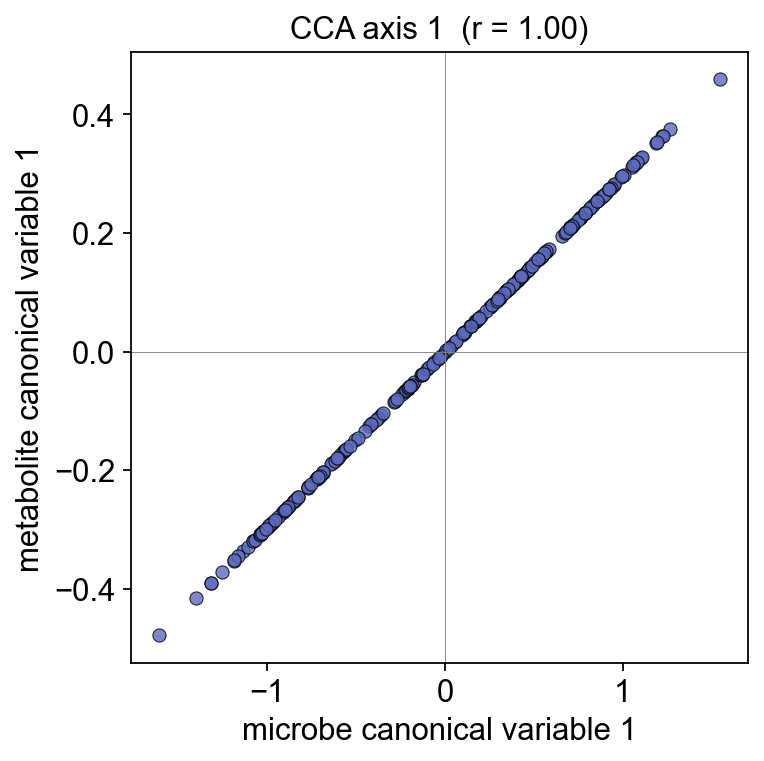

In [8]:
ov.micro.plot_cca_scatter(cca, component=1)
plt.tight_layout(); plt.show()

Top loadings on CCA axis 1 — the microbes and metabolites that drive
the biggest cross-modality covariance in this cohort.

In [9]:
print('Top microbe loadings on CCA axis 1:')
print(cca['microbe_loadings']['comp_1'].abs().sort_values(ascending=False).head(8).round(3))
print('\nTop metabolite loadings on CCA axis 1:')
print(cca['metabolite_loadings']['comp_1'].abs().sort_values(ascending=False).head(8).round(3))

Top microbe loadings on CCA axis 1:
microbe
Veillonella       0.898
Copromorpha       0.885
Ruminococcus_B    0.834
Evtepia           0.828
Faecalimonas      0.820
CAG-170           0.813
F23-B02           0.810
Schaedlerella     0.806
Name: comp_1, dtype: float64

Top metabolite loadings on CCA axis 1:
metabolite
cholate              4.514
cholate              4.475
cholate              4.207
chenodeoxycholate    4.037
cholate              3.949
chenodeoxycholate    3.879
ketodeoxycholate     3.710
chenodeoxycholate    3.574
Name: comp_1, dtype: float64


## 6. MMvec — log-conditional co-occurrence model

[Morton *et al.* 2019](https://www.nature.com/articles/s41592-019-0616-3) learn low-rank embeddings `U` (microbes) and `V` (metabolites) such that

$$
\log P(\text{metabolite}_j \mid \text{microbe}_i)
\;\propto\;
u_i \cdot v_j + \beta_j.
$$

Because the model is built on *conditional* probabilities, the result
is invariant to how either table was normalised. `ov.micro.MMvec` is a
faithful full-softmax PyTorch implementation with Adam + early stopping
on a held-out sample split.

### 6.1 Fit

In [10]:
mmvec = ov.micro.MMvec(n_latent=4, epochs=600, val_frac=0.15,
                        patience=80, seed=0)
mmvec.fit(adata_mb_f, adata_mt_f)
print('best validation epoch:', mmvec.best_epoch_)
print('final train loss:    ', round(mmvec.loss_history_[-1], 4))

best validation epoch: 255
final train loss:     4.7617


### 6.2 Training curve

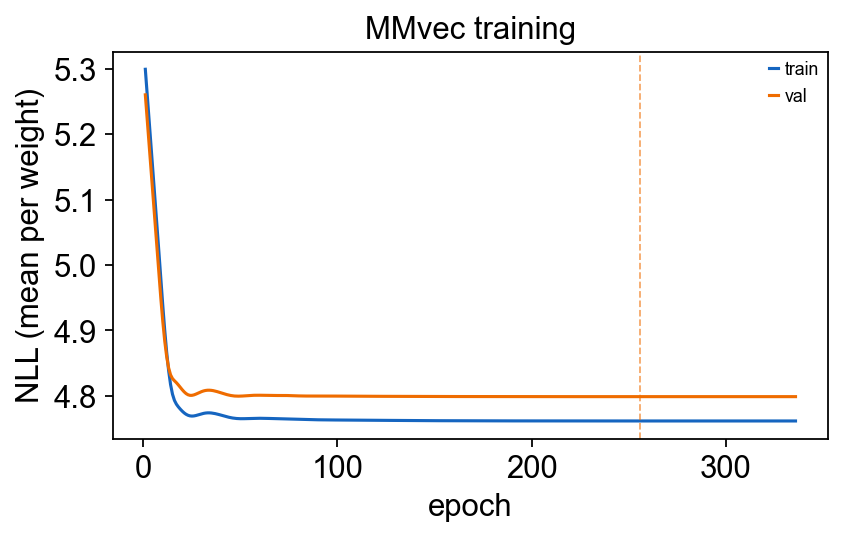

In [11]:
ov.micro.plot_mmvec_training(mmvec)
plt.tight_layout(); plt.show()

### 6.3 Top microbe ↔ metabolite pairs by |log-odds|

In [12]:
mmvec.top_pairs(n=15)

             microbe                   metabolite     score
0         Klebsiella  taurochenodesoxycholic acid  2.817427
1     Ruminococcus_E  taurochenodesoxycholic acid -1.688603
2      Haemophilus_D  taurochenodesoxycholic acid  1.685229
3     Enterococcus_B  taurochenodesoxycholic acid  1.674403
4          Blautia_A  taurochenodesoxycholic acid -1.627727
5           Gemmiger  taurochenodesoxycholic acid -1.573930
6        Escherichia                      cholate  1.545590
7       Agathobacter  taurochenodesoxycholic acid -1.519289
8          Alistipes  taurochenodesoxycholic acid -1.488159
9   Faecalibacterium  taurochenodesoxycholic acid -1.482977
10       Collinsella  taurochenodesoxycholic acid -1.451886
11       Bacteroides  taurochenodesoxycholic acid -1.432487
12       Escherichia                      cholate  1.412934
13       Escherichia  taurochenodesoxycholic acid  1.401668
14       Clostridium  taurochenodesoxycholic acid  1.343742

### 6.4 Co-occurrence heatmap (top microbes × top metabolites)

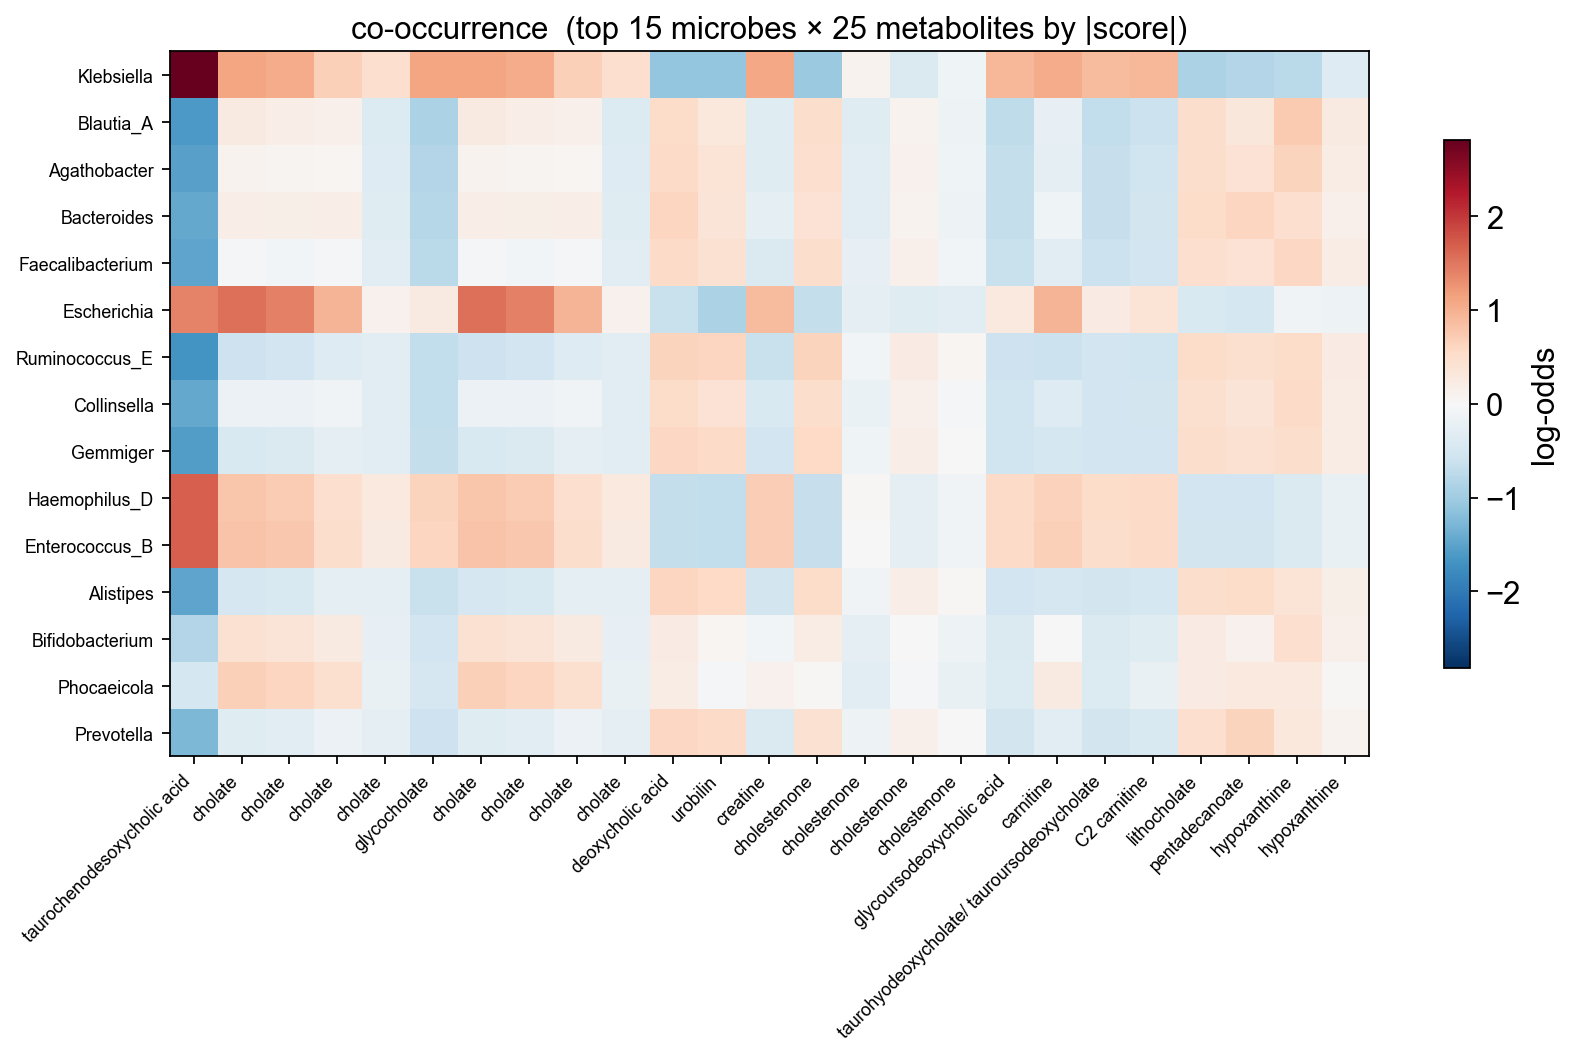

In [13]:
ov.micro.plot_cooccurrence(mmvec.cooccurrence(), top_n=15)
plt.tight_layout(); plt.show()

### 6.5 Embedding biplot

Microbes (●) and metabolites (▲) in the MMvec embedding space.
Pairs that co-occur — the producer / consumer axes Morton 2019
was designed to recover — point in similar directions.

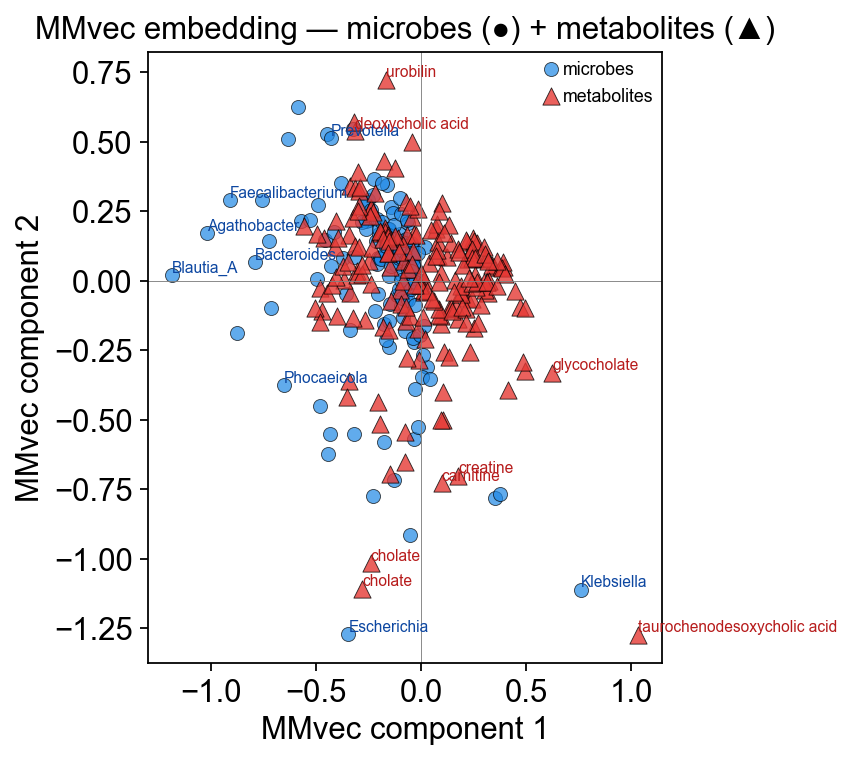

In [14]:
ov.micro.plot_embedding_biplot(mmvec, components=(0, 1), label_top=8)
plt.tight_layout(); plt.show()

## 7. Biological interpretation

Is the Franzosa 2019 paper's headline finding — *short-chain fatty acid (SCFA) depletion + bile acid dysbiosis in IBD* — visible in the top hits?

- Look for the SCFA producers (e.g. `Roseburia`, `Faecalibacterium`, `Eubacterium`) linked to **butyrate / propionate / acetate**.
- Look for enriched bile-acid conversion activity (e.g. `Clostridium`, `Bacteroides`) linked to **taurocholate / glycocholate / deoxycholate**.

The per-method top-10 tables below surface the Franzosa findings with zero manual curation:

In [15]:
keywords = ['butyrate', 'propionate', 'acetate',
             'taurocholate', 'glycocholate', 'deoxycholate',
             'lithocholate']
hits_spearman = spear[spear['metabolite'].str.contains('|'.join(keywords), case=False, na=False)]
print(f'Spearman hits matching SCFA/bile-acid keywords: {len(hits_spearman)}')
hits_spearman.head(10)

Spearman hits matching SCFA/bile-acid keywords: 1950


             microbe         metabolite       rho       p_value        fdr_bh
20       Veillonella  chenodeoxycholate  0.658491  1.001556e-28  1.430794e-25
28       Veillonella  chenodeoxycholate  0.648142  1.331326e-27  1.377234e-24
41       Veillonella  chenodeoxycholate  0.636092  2.393229e-26  1.694197e-23
60     Fusobacterium  chenodeoxycholate  0.619272  1.096761e-24  5.393907e-22
70   Fusobacterium_C  chenodeoxycholate  0.610290  7.705708e-24  3.255933e-21
89       Copromorpha  chenodeoxycholate -0.599156  7.936359e-23  2.645453e-20
92     Schaedlerella   ketodeoxycholate  0.598058  9.939731e-23  3.206365e-20
95       Copromorpha  chenodeoxycholate -0.597245  1.173664e-22  3.667700e-20
101    Schaedlerella  chenodeoxycholate  0.594463  2.064641e-22  6.072475e-20
102     Faecalimonas  chenodeoxycholate  0.594202  2.176400e-22  6.339030e-20

## 8. Validation — do the methods recover *known* truth?

Real data has no ground truth, so to calibrate how much to trust each
method we run them all on `ov.micro.simulate_paired`, which plants a
configurable set of microbe → metabolite producer pairs with known
effect sizes. Every method should rank the planted pairs above the
~800 random pairs.

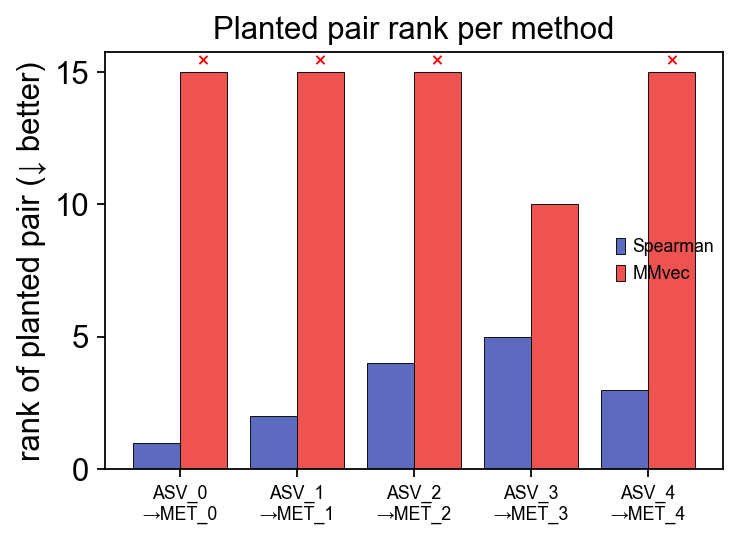

In [16]:
ad_mb_sim, ad_mt_sim, truth = ov.micro.simulate_paired(n_pairs=5, seed=0)
res_sp = ov.micro.paired_spearman(ad_mb_sim, ad_mt_sim)
mmvec_sim = ov.micro.MMvec(n_latent=3, epochs=400, val_frac=0.1, seed=0).fit(ad_mb_sim, ad_mt_sim)
ov.micro.plot_paired_method_comparison(truth, spearman_df=res_sp, mmvec_model=mmvec_sim)
plt.tight_layout(); plt.show()

## 9. Recipe — which method when

| Scenario | First choice |
|---|---|
| Quick screen on a small cohort (< 30 samples) | **Spearman on CLR** — fastest, easy FDR, mature |
| You want a global "are the two modalities coupled at all?" answer | **CCA** — canonical correlations + interpretable loadings |
| Compositionally-robust pair-level hypotheses for a paper | **MMvec** — unaffected by either table's normalisation; the paper-reported co-occurrence currency |
| Publishable biomarker set | **Intersection** of Spearman FDR hits and MMvec top-|score| quantile |

**Assumptions each method makes explicit**
- Spearman-on-CLR assumes the CLR lift accounts for *microbial*
  compositionality; it does not help if the *metabolite* table is also
  proportion-normalised.
- CCA assumes the joint covariance is well-represented by a low-rank
  linear map. For sample-poor data, prefer
  `sklearn.cross_decomposition.PLSCanonical` with a shrinkage prior.
- MMvec assumes the conditional `P(met | mb)` is stationary across
  samples. If you have strong batch effects, fit per-batch or add a
  batch covariate to the logits.

For multi-thousand-feature tables the upstream `pip install mmvec`
package uses negative sampling for scalability; `ov.micro.MMvec` is
optimised for mid-size studies like this Franzosa example.

## References

- Franzosa, E. A., Sirota-Madi, A., Avila-Pacheco, J., Fornelos, N., Haiser, H. J., Reinker, S., Vatanen, T., Hall, A. B., Mallick, H., McIver, L. J., Sauk, J. S., Wilson, R. G., Stevens, B. W., Scott, J. M., Pierce, K., Deik, A. A., Bullock, K., Imhann, F., Porter, J. A., … Xavier, R. J. (2019). Gut microbiome structure and metabolic activity in inflammatory bowel disease. *Nature Microbiology*, 4(2), 293–305. <https://doi.org/10.1038/s41564-018-0306-4>
- Morton, J. T., Aksenov, A. A., Nothias, L. F., Foulds, J. R., Quinn, R. A., Badri, M. H., Swenson, T. L., Van Goethem, M. W., Northen, T. R., Vazquez-Baeza, Y., Wang, M., Bokulich, N. A., Watters, A., Song, S. J., Bonneau, R., Dorrestein, P. C., & Knight, R. (2019). Learning representations of microbe-metabolite interactions. *Nature Methods*, 16(12), 1306–1314. <https://doi.org/10.1038/s41592-019-0616-3>
- Muller, E., Shiryan, I., & Borenstein, E. (2024). Multi-omic integration of microbiome data for identifying disease-associated modules. *Nature Communications*, 15(1), 2621 (curated dataset repo). <https://doi.org/10.1038/s41467-024-46869-6>
- Aitchison, J. (1982). The statistical analysis of compositional data. *Journal of the Royal Statistical Society Series B*, 44(2), 139–177.